In [15]:
import torch
import sys
import os
import matplotlib.pyplot as plt

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from dmg.models.neural_networks.calibrate import Calibrate

print(f"Project root added: {project_root}")

Project root added: /workspace/my_deltamodel/project/diff_compare


In [16]:
def load_state_dict_from_file(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    
    ckpt = torch.load(path, map_location='cpu')
    
    # Handle different saving formats
    if isinstance(ckpt, dict):
        if 'model' in ckpt:
            return ckpt['model']
        elif 'state_dict' in ckpt:
            return ckpt['state_dict']
        return ckpt
    return ckpt

def compare_checkpoints(path1, path2, param_name='params'):
    print(f"Loading {path1}...")
    state1 = load_state_dict_from_file(path1)
    print(f"Loading {path2}...")
    state2 = load_state_dict_from_file(path2)
    
    # Handle DataParallel/DDP prefix 'module.'
    keys1 = list(state1.keys())
    keys2 = list(state2.keys())
    
    # Try to find the specific parameter
    key1 = next((k for k in keys1 if k.endswith(param_name)), None)
    key2 = next((k for k in keys2 if k.endswith(param_name)), None)
    
    if key1 is None or key2 is None:
        print(f"❌ Parameter ending with '{param_name}' not found.")
        print("Keys in file 1:", keys1)
        return
        
    print(f"Comparing parameter: '{key1}'")
    
    p1 = state1[key1]
    p2 = state2[key2]
    
    diff = (p1 - p2)
    abs_diff = diff.abs()
    
    mean_diff = abs_diff.mean().item()
    max_diff = abs_diff.max().item()
    std_diff = abs_diff.std().item()
    
    print(f"-" * 30)
    print(f"Mean Abs Diff: {mean_diff:.6e}")
    print(f"Max Abs Diff:  {max_diff:.6e}")
    print(f"Std Dev Diff:  {std_diff:.6e}")
    
    if max_diff > 0:
        print("✅ Parameters CHANGE detected.")
        
        # Visualize difference
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.hist(abs_diff.flatten().numpy(), bins=50)
        plt.title("Histogram of Parameter Differences")
        plt.xlabel("Absolute Difference")
        
        plt.subplot(1, 2, 2)
        # Show a slice of the parameters difference
        # params shape is (num_basins, ny, num_start)
        if diff.ndim >= 2:
             # Visualizing slice for first basin
             plt.imshow(diff[0, -2:-1, :].numpy(), aspect='auto', cmap='bwr')
             plt.colorbar()
             plt.title("Diff Heatmap (Basin 0)")
        plt.tight_layout()
        plt.show()
        
    else:
        print("⚠️ Parameters correspond to IDENTICAL values (No update).")

Loading /workspace/my_deltamodel/project/diff_compare/output/camels_559/train1989-1998/no_multi/Calibrate_E50_R365_B100_n16_noLn_noWU_42/Gr4j/KgeLoss/stat/dGr4j_Ep10.pt...
Loading /workspace/my_deltamodel/project/diff_compare/output/camels_559/train1989-1998/no_multi/Calibrate_E50_R365_B100_n16_noLn_noWU_42/Gr4j/KgeLoss/stat/dGr4j_Ep20.pt...
Comparing parameter: 'nn_model.params'
------------------------------
Mean Abs Diff: 1.667775e-01
Max Abs Diff:  1.074066e+00
Std Dev Diff:  1.936888e-01
✅ Parameters CHANGE detected.


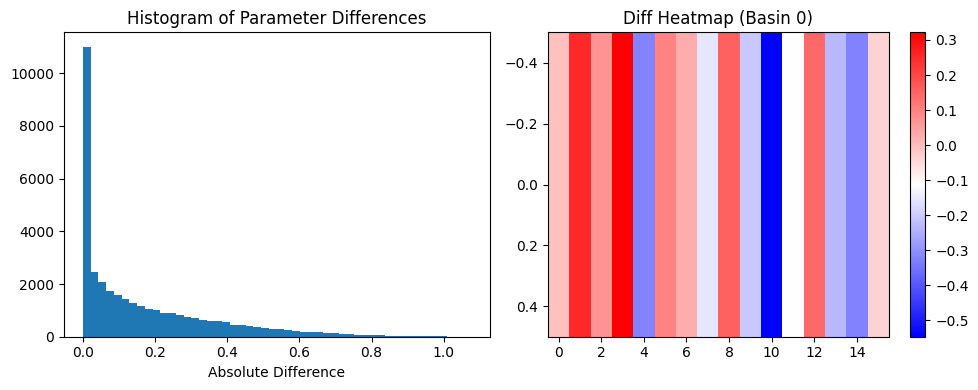

In [17]:
# Set your file paths here
# Example:
file_epoch_0 = '/workspace/my_deltamodel/project/diff_compare/output/camels_559/train1989-1998/no_multi/Calibrate_E50_R365_B100_n16_noLn_noWU_42/Gr4j/KgeLoss/stat/dGr4j_Ep10.pt'
file_epoch_1 = '/workspace/my_deltamodel/project/diff_compare/output/camels_559/train1989-1998/no_multi/Calibrate_E50_R365_B100_n16_noLn_noWU_42/Gr4j/KgeLoss/stat/dGr4j_Ep20.pt'


compare_checkpoints(file_epoch_0, file_epoch_1)